In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# lin-lora / scaled-lora investigation

Companion to `docs/notes/lin_scaled_lora_investigation.md`. One notebook section per hypothesis (H1–H5). Sweeps land in `../logs/{h1_diag_2k,h3_rsweep_2k,h4_post_2k}/run_info/logs/`.

Compute / plot are split per CLAUDE.md notebook rule: compute cells produce dicts/dataframes, plot cells only read and draw. Re-running a plot cell never triggers a sweep re-load.

In [9]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

LOGS = Path("../logs")


def _backfill_lr_from_command(config):
    """Older runs (e.g. optim_compare_2k_1ep) don't log 'lr' as a top-level key — only in command."""
    if config is None or "lr" in config:
        return config
    cmd = config.get("command", "")
    m = re.search(r"--lr\s+(\S+)", cmd)
    if m:
        try:
            config["lr"] = float(m.group(1))
        except ValueError:
            pass
    return config


def load_run(log_path):
    """Parse a JSONL log file produced by train_lora.py. Returns (config, evals, optim_steps).

    config: the single `config` event (dict) emitted at startup, or None.
    evals: list of `eval` events.
    optim_steps: list of `optim_step` events (only present for runs with --log_optim_diagnostics).
    """
    config, evals, optim_steps = None, [], []
    for line in Path(log_path).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue
        ev = obj.get("event")
        if ev == "config":
            config = obj
        elif ev == "eval":
            evals.append(obj)
        elif ev == "optim_step":
            optim_steps.append(obj)
    config = _backfill_lr_from_command(config)
    return config, evals, optim_steps


def load_sweep(group):
    """Load every .out file under logs/<group>/run_info/logs/."""
    log_dir = LOGS / group / "run_info" / "logs"
    runs = []
    if not log_dir.exists():
        return runs
    for f in sorted(log_dir.glob("*.out")):
        if f.stat().st_size == 0:
            continue
        config, evals, optim_steps = load_run(f)
        if config is not None and evals and "lr" in config:
            runs.append((config, evals, optim_steps))
    return runs


def best_per(group_runs, key_fn):
    """For each unique key returned by key_fn(config), keep the run with lowest final eval_loss."""
    best = {}
    for cfg, evs, _ in group_runs:
        k = key_fn(cfg)
        fl = evs[-1]["eval_loss"]
        if k not in best or fl < best[k][2]:
            best[k] = (cfg, evs, fl)
    return best

## H1 — Adam's v̂⁻¹ᶠ² erases the geometric correction?

Logged every 20 steps inside `AdamLinLoRA.step()` / `AdamScaledLoRA.step()` when `--log_optim_diagnostics` is set:
- per-pair `cos(Δ_lin, Δ_adamw_raw)` for A and B factors (median/min/max across LoRA pairs)
- Frobenius norms of Δ_lin and Δ_adamw_raw
- ‖A‖_F, ‖B‖_F, eigenvalue extremes of S_A and S_B

**Falsifier:** if cos_median > 0.95 throughout, H1 confirmed; if cos < 0.7 yet final losses match, H1 wrong.

In [10]:
h1_runs = load_sweep("h1_diag_2k")
print(f"Loaded {len(h1_runs)} runs from h1_diag_2k")
for cfg, evs, opt in h1_runs:
    print(f"  {cfg['optimizer']:20s} η={cfg['lr']:.0e} steps={evs[-1]['step']} "
          f"final_eval={evs[-1]['eval_loss']:.4f} optim_step_events={len(opt)}")

Loaded 2 runs from h1_diag_2k
  adam-lin-lora        η=1e-03 steps=2000 final_eval=0.7581 optim_step_events=100
  adam-scaled-lora     η=1e-03 steps=2000 final_eval=0.7592 optim_step_events=100


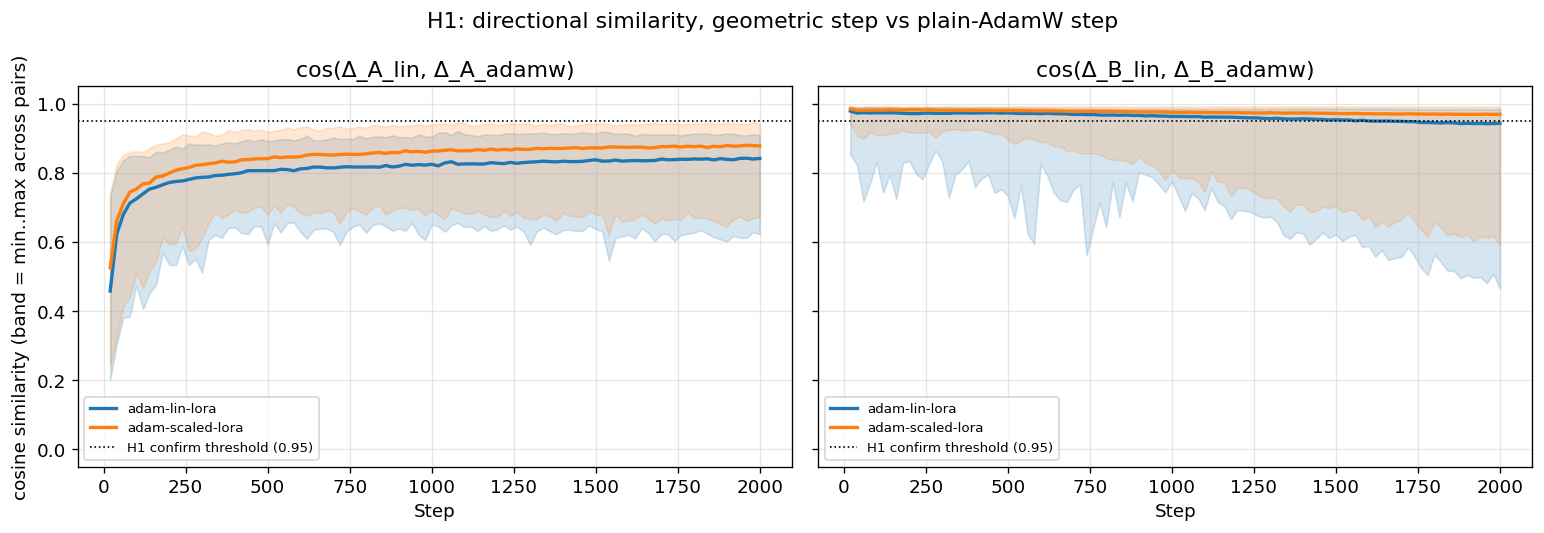

In [11]:
if h1_runs:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for ax, factor in zip(axes, ["A", "B"]):
        for cfg, evs, opt in sorted(h1_runs, key=lambda r: r[0]["optimizer"]):
            if not opt:
                continue
            steps = [e["step"] for e in opt]
            med = [e[f"cos_{factor}_median"] for e in opt]
            lo = [e[f"cos_{factor}_min"] for e in opt]
            hi = [e[f"cos_{factor}_max"] for e in opt]
            (line,) = ax.plot(steps, med, label=cfg["optimizer"], lw=2)
            ax.fill_between(steps, lo, hi, alpha=0.18, color=line.get_color())
        ax.axhline(0.95, ls=":", color="black", lw=1, label="H1 confirm threshold (0.95)")
        ax.set_xlabel("Step")
        ax.set_title(f"cos(Δ_{factor}_lin, Δ_{factor}_adamw)")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        if factor == "A":
            ax.set_ylabel("cosine similarity (band = min..max across pairs)")
        ax.legend(fontsize=8)
    fig.suptitle("H1: directional similarity, geometric step vs plain-AdamW step")
    fig.tight_layout(); plt.show()

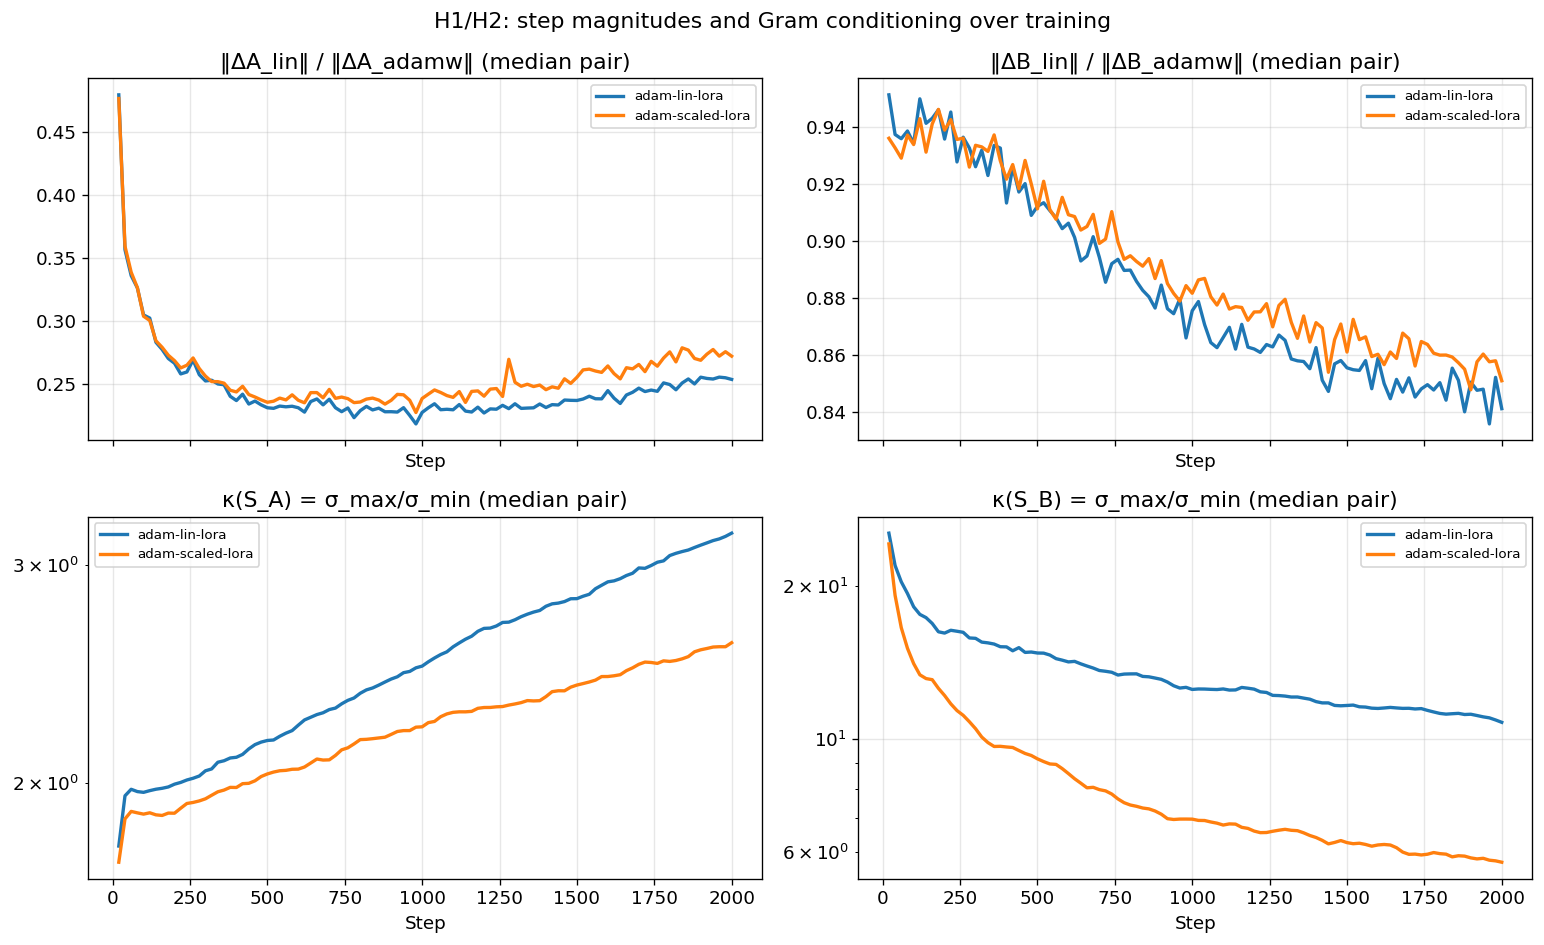

In [12]:
if h1_runs:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
    for cfg, evs, opt in sorted(h1_runs, key=lambda r: r[0]["optimizer"]):
        if not opt:
            continue
        steps = [e["step"] for e in opt]
        # Norm ratios: how much smaller/larger is the geometric step than AdamW?
        rA = [e["norm_dA_lin_median"] / max(e["norm_dA_raw_median"], 1e-30) for e in opt]
        rB = [e["norm_dB_lin_median"] / max(e["norm_dB_raw_median"], 1e-30) for e in opt]
        # Conditioning: how poorly conditioned are S_A, S_B over training?
        cA = [e["SA_max_median"] / max(e["SA_min_median"], 1e-30) for e in opt]
        cB = [e["SB_max_median"] / max(e["SB_min_median"], 1e-30) for e in opt]
        axes[0, 0].plot(steps, rA, label=cfg["optimizer"], lw=2)
        axes[0, 1].plot(steps, rB, label=cfg["optimizer"], lw=2)
        axes[1, 0].plot(steps, cA, label=cfg["optimizer"], lw=2)
        axes[1, 1].plot(steps, cB, label=cfg["optimizer"], lw=2)
    for ax, title in zip(
        axes.flat,
        ["‖ΔA_lin‖ / ‖ΔA_adamw‖ (median pair)",
         "‖ΔB_lin‖ / ‖ΔB_adamw‖ (median pair)",
         "κ(S_A) = σ_max/σ_min (median pair)",
         "κ(S_B) = σ_max/σ_min (median pair)"],
    ):
        ax.set_title(title); ax.set_xlabel("Step"); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    axes[1, 0].set_yscale("log"); axes[1, 1].set_yscale("log")
    fig.suptitle("H1/H2: step magnitudes and Gram conditioning over training")
    fig.tight_layout(); plt.show()

## H4 — Productive: reorder Adam and the geometric solve

`AdamLinLoRAPost` / `AdamScaledLoRAPost` run Adam on raw gradients, then apply the Sylvester / Gram solve to the Adam *step* (not the gradient). This preserves Adam's adaptive scale per-coord while reinstalling the (A,B)-coupled rotation.

Success bar: best `*-post` final eval ≤ 0.7479 (≥ 0.010 below AdamW's 0.7579).

In [13]:
h4_runs = load_sweep("h4_post_2k")
# Bring AdamW + original adam-{lin,scaled}-lora reference points from prior sweeps
ref_runs = []
for grp in ("optim_compare_high_eta_2k", "lr_sweep_2k", "optim_compare_2k_1ep"):
    for cfg, evs, _ in load_sweep(grp):
        if cfg["optimizer"] in {"adamw", "adam-lin-lora", "adam-scaled-lora"}:
            ref_runs.append((cfg, evs, []))

print(f"H4 runs: {len(h4_runs)}")
for cfg, evs, _ in sorted(h4_runs, key=lambda r: (r[0]["optimizer"], r[0]["lr"])):
    print(f"  {cfg['optimizer']:24s} η={cfg['lr']:.0e} final={evs[-1]['eval_loss']:.4f}")
print()
print(f"Reference runs: {len(ref_runs)}")

H4 runs: 10
  adam-lin-lora-post       η=3e-05 final=0.8456
  adam-lin-lora-post       η=1e-04 final=0.8395
  adam-lin-lora-post       η=3e-04 final=0.8274
  adam-lin-lora-post       η=1e-03 final=0.7875
  adam-lin-lora-post       η=3e-03 final=0.8450
  adam-scaled-lora-post    η=3e-05 final=0.8162
  adam-scaled-lora-post    η=1e-04 final=0.8305
  adam-scaled-lora-post    η=3e-04 final=0.8519
  adam-scaled-lora-post    η=1e-03 final=0.8351
  adam-scaled-lora-post    η=3e-03 final=0.8576

Reference runs: 21


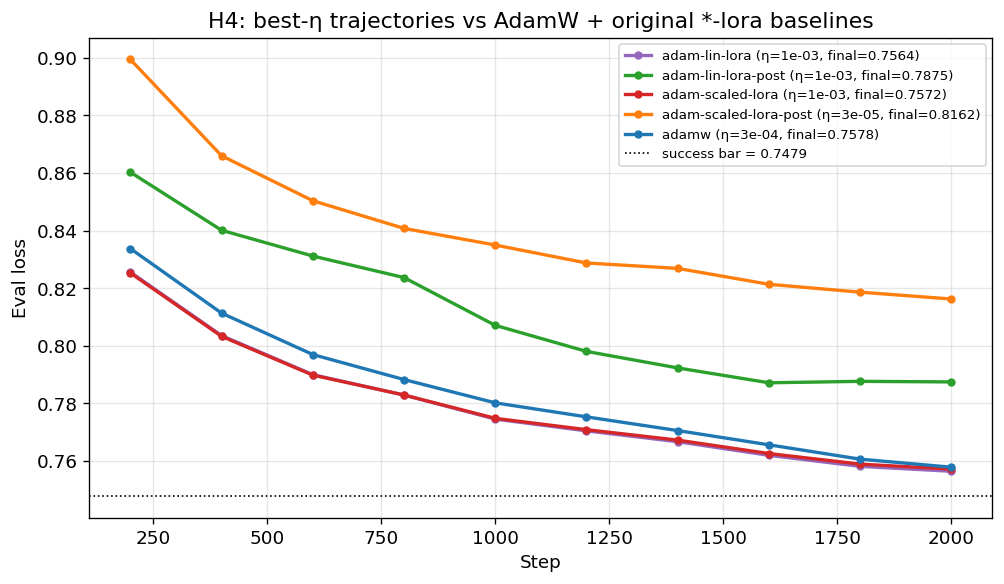

In [14]:
if h4_runs:
    DIVERGE = 1.5
    keep = [r for r in h4_runs + ref_runs if max(e["eval_loss"] for e in r[1]) < DIVERGE]
    best = best_per(keep, lambda c: c["optimizer"])

    COLORS = {
        "adamw":                  "#1f77b4",
        "adam-lin-lora":          "#9467bd",
        "adam-scaled-lora":       "#d62728",
        "adam-lin-lora-post":     "#2ca02c",
        "adam-scaled-lora-post":  "#ff7f0e",
    }
    BAR = 0.7479

    fig, ax = plt.subplots(figsize=(8.5, 5))
    for opt, (cfg, evs, fl) in sorted(best.items()):
        steps = [e["step"] for e in evs]
        losses = [e["eval_loss"] for e in evs]
        ax.plot(steps, losses, color=COLORS.get(opt, "grey"), marker="o", markersize=4, lw=2,
                label=f"{opt} (η={cfg['lr']:.0e}, final={fl:.4f})")
    ax.axhline(BAR, ls=":", color="black", lw=1, label=f"success bar = {BAR}")
    ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
    ax.grid(True, alpha=0.3)
    ax.set_title("H4: best-η trajectories vs AdamW + original *-lora baselines")
    ax.legend(fontsize=8, loc="upper right")
    fig.tight_layout(); plt.show()

## H3 — Does the geometric advantage widen at small r?

Sweep over r ∈ {2, 4, 64} × {adamw, adam-lin-lora, adam-scaled-lora} × η ∈ {3e-4, 1e-3}. r=16 already in `optim_compare_high_eta_2k`. Plot eval-loss(r) per optimizer for the best η.

In [15]:
h3_runs = load_sweep("h3_rsweep_2k")
# Augment with r=16 entries from prior sweeps (same optimizers + ηs)
for grp in ("optim_compare_high_eta_2k", "lr_sweep_2k"):
    for cfg, evs, _ in load_sweep(grp):
        if cfg["optimizer"] in {"adamw", "adam-lin-lora", "adam-scaled-lora"} and cfg["lr"] in (3e-4, 1e-3):
            h3_runs.append((cfg, evs, []))

print(f"H3 + r=16 reference runs: {len(h3_runs)}")
rows = sorted({(c["optimizer"], int(c.get("lora_r", 16)), c["lr"]) for c, _, _ in h3_runs})
for opt, r, lr in rows:
    matches = [evs for c, evs, _ in h3_runs
               if c["optimizer"] == opt and int(c.get("lora_r", 16)) == r and c["lr"] == lr]
    if matches:
        fl = matches[0][-1]["eval_loss"]
        print(f"  {opt:18s}  r={r:<3d}  η={lr:.0e}  final={fl:.4f}")

H3 + r=16 reference runs: 24
  adam-lin-lora       r=2    η=3e-04  final=0.8150
  adam-lin-lora       r=2    η=1e-03  final=0.7914
  adam-lin-lora       r=4    η=3e-04  final=0.8024
  adam-lin-lora       r=4    η=1e-03  final=0.7782
  adam-lin-lora       r=16   η=3e-04  final=0.7723
  adam-lin-lora       r=16   η=1e-03  final=0.7564
  adam-lin-lora       r=64   η=3e-04  final=0.7527
  adam-lin-lora       r=64   η=1e-03  final=0.7747
  adam-scaled-lora    r=2    η=3e-04  final=0.8134
  adam-scaled-lora    r=2    η=1e-03  final=0.7909
  adam-scaled-lora    r=4    η=3e-04  final=0.8001
  adam-scaled-lora    r=4    η=1e-03  final=0.7777
  adam-scaled-lora    r=16   η=3e-04  final=0.7702
  adam-scaled-lora    r=16   η=1e-03  final=0.7572
  adam-scaled-lora    r=64   η=3e-04  final=0.7506
  adam-scaled-lora    r=64   η=1e-03  final=0.7774
  adamw               r=2    η=3e-04  final=0.7920
  adamw               r=2    η=1e-03  final=0.7834
  adamw               r=4    η=3e-04  final=0.7807
  

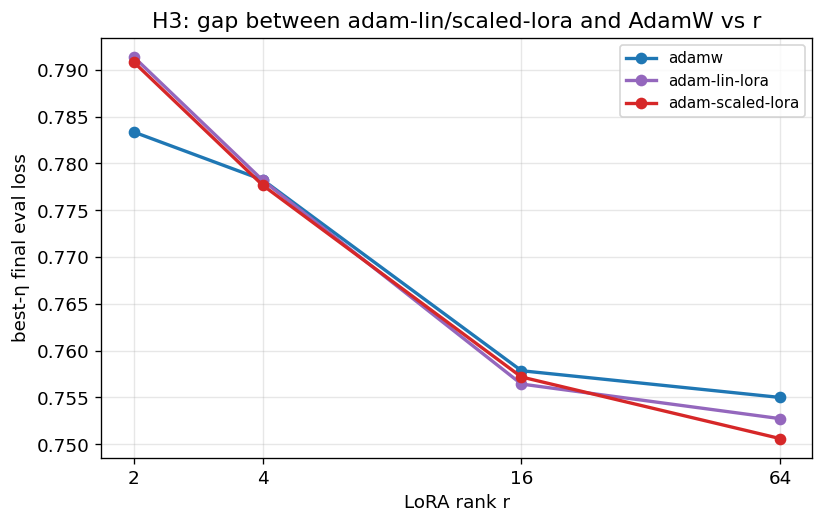

In [16]:
if h3_runs:
    # For each (optimizer, r) keep best η
    best = {}
    for cfg, evs, _ in h3_runs:
        k = (cfg["optimizer"], int(cfg.get("lora_r", 16)))
        fl = evs[-1]["eval_loss"]
        if k not in best or fl < best[k][2]:
            best[k] = (cfg, evs, fl)

    COLORS = {"adamw": "#1f77b4", "adam-lin-lora": "#9467bd", "adam-scaled-lora": "#d62728"}
    fig, ax = plt.subplots(figsize=(7, 4.5))
    rs = sorted({k[1] for k in best})
    for opt in ["adamw", "adam-lin-lora", "adam-scaled-lora"]:
        xs, ys = [], []
        for r in rs:
            entry = best.get((opt, r))
            if entry is None:
                continue
            xs.append(r); ys.append(entry[2])
        ax.plot(xs, ys, marker="o", lw=2, color=COLORS.get(opt, "grey"), label=opt)
    ax.set_xscale("log", base=2)
    ax.set_xticks(rs); ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.set_xlabel("LoRA rank r"); ax.set_ylabel("best-η final eval loss")
    ax.grid(True, alpha=0.3)
    ax.set_title("H3: gap between adam-lin/scaled-lora and AdamW vs r")
    ax.legend(fontsize=9)
    fig.tight_layout(); plt.show()

## Leaderboard (auto-generated)

Best-η final eval loss per optimizer at r=16 across all sweeps loaded above. Success bar 0.7479.

In [17]:
all_runs = []
for grp in ("h1_diag_2k", "h4_post_2k", "optim_compare_high_eta_2k", "lr_sweep_2k", "optim_compare_2k_1ep"):
    for cfg, evs, _ in load_sweep(grp):
        if int(cfg.get("lora_r", 16)) == 16:
            all_runs.append((cfg, evs, _))
best = best_per(all_runs, lambda c: c["optimizer"])
rows = sorted(best.items(), key=lambda kv: kv[1][2])
BAR = 0.7479
print(f"{'rank':>4}  {'optimizer':24s}  {'best η':>8s}  {'eval':>7s}  vs bar")
for i, (opt, (cfg, evs, fl)) in enumerate(rows, 1):
    margin = BAR - fl
    flag = "✓ BEAT" if margin > 0 else ("~" if margin > -0.005 else "")
    print(f"{i:>4d}  {opt:24s}  {cfg['lr']:>8.0e}  {fl:>7.4f}  {margin:+.4f} {flag}")

rank  optimizer                   best η     eval  vs bar
   1  adam-lin-lora                1e-03   0.7564  -0.0085 
   2  adam-scaled-lora             1e-03   0.7572  -0.0093 
   3  adamw                        3e-04   0.7578  -0.0099 
   4  adam-lin-lora-post           1e-03   0.7875  -0.0396 
   5  adam-scaled-lora-post        3e-05   0.8162  -0.0683 
   6  lin-lora                     1e-02   0.8457  -0.0978 
   7  scaled-lora                  1e-02   0.8744  -0.1265 
